In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = "drive/MyDrive/"
data = pd.read_csv(path + "Train_rev1.zip", compression='zip', index_col=None)
data.shape

(244768, 12)

In [ ]:
data.head()

,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName
0,12612628,Engineering Systems Analyst,Engineering Systems Analyst Dorking Surrey Sal...,"Dorking, Surrey, Surrey",Dorking,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk
1,12612830,Stress Engineer Glasgow,Stress Engineer Glasgow Salary **** to **** We...,"Glasgow, Scotland, Scotland",Glasgow,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 35000/annum 25-35K,30000,cv-library.co.uk
2,12612844,Modelling and simulation analyst,Mathematical Modeller / Simulation Analyst / O...,"Hampshire, South East, South East",Hampshire,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 40000/annum 20-40K,30000,cv-library.co.uk
3,12613049,Engineering Systems Analyst / Mathematical Mod...,Engineering Systems Analyst / Mathematical Mod...,"Surrey, South East, South East",Surrey,NaN,permanent,Gregory Martin International,Engineering Jobs,25000 - 30000/annum 25K-30K negotiable,27500,cv-library.co.uk
4,12613647,"Pioneer, Miser Engineering Systems Analyst","Pioneer, Miser Engineering Systems Analyst Do...","Surrey, South East, South East",Surrey,NaN,permanent,Gregory Martin International,Engineering Jobs,20000 - 30000/annum 20-30K,25000,cv-library.co.uk


One problem with salary prediction is that it's oddly distributed: there are many people who are paid standard salaries and a few that get tons o money. The distribution is fat-tailed on the right side, which is inconvenient for MSE minimization.

There are several techniques to combat this: using a different loss function, predicting log-target instead of raw target or even replacing targets with their percentiles among all salaries in the training set. We gonna use logarithm for now.

_You can read more [in the official description](https://www.kaggle.com/c/job-salary-prediction#description)._

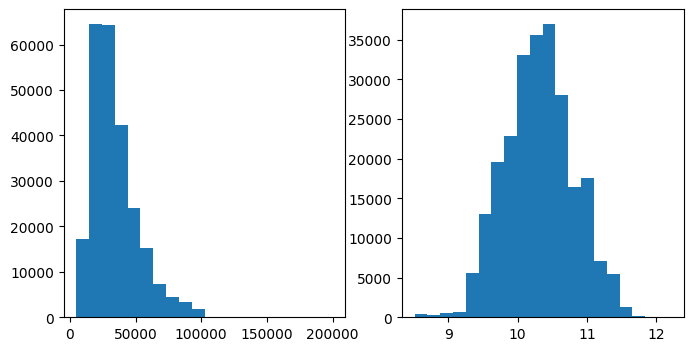

In [ ]:
data['Log1pSalary'] = np.log1p(data['SalaryNormalized']).astype('float32')

plt.figure(figsize=[8, 4])
plt.subplot(1, 2, 1)
plt.hist(data["SalaryNormalized"], bins=20);

plt.subplot(1, 2, 2)
plt.hist(data['Log1pSalary'], bins=20);

In [ ]:
text_columns = ["Title", "FullDescription"]
categorical_columns = ["Category", "Company", "LocationNormalized", "ContractType", "ContractTime"]
TARGET_COLUMN = "Log1pSalary"

data[categorical_columns] = data[categorical_columns].fillna('NaN') # cast missing values to string "NaN"

data.sample(3)

,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName,Log1pSalary
199003,71849627,Fantastic Opportunity with Stunning Restaurant...,Fantastic Opportunity with Stunning Restaurant...,Cheshire North West,Cheshire,NaN,permanent,Corecruitment International,Hospitality & Catering Jobs,19000 Per Annum bonus,19000,totaljobs.com,9.852247
13573,66606414,Data Configuration Engineer,Exciting opportunity for a Data Configuration ...,Cambridge,Cambridge,NaN,permanent,NaN,IT Jobs,21000 - 25000 per annum,23000,theitjobboard.co.uk,10.043293
19875,67106583,Materials Analyst,My Client is looking to recruit an experienced...,Redditch,Redditch,full_time,NaN,NaN,Other/General Jobs,"28,000.00 - 30,000.00 per year",29000,Jobcentre Plus,10.275085


In [ ]:
def data_string_token(data_string):
  return ' '.join(tokenizer.tokenize(str(data_string))).lower()  # we use str(data_string) to tokenize None objects as well as valid strings

In [ ]:
import nltk
#TODO YOUR CODE HERE

tokenizer = nltk.tokenize.WordPunctTokenizer()
# YOUR CODE HERE
data["Title"] = data["Title"].apply(data_string_token)
data["FullDescription"] = data["FullDescription"].apply(data_string_token)


In [ ]:
from collections import Counter
token_counts = Counter()

# Count how many times does each token occur in both "Title" and "FullDescription" in total
#TODO <YOUR CODE>
for title in data["Title"]:
  token_counts.update(title.split())

for desc in data["FullDescription"]:
  token_counts.update(desc.split())


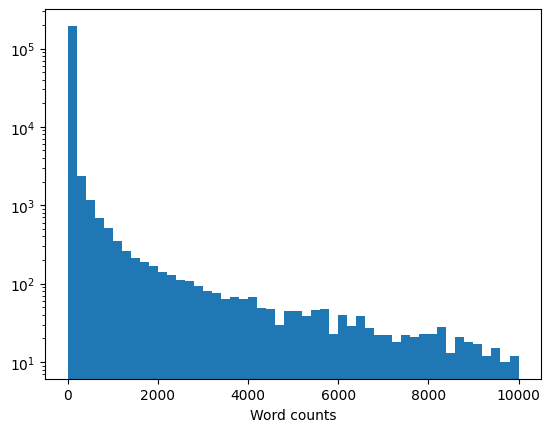

In [ ]:
# Let's see how many words are there for each count
plt.hist(list(token_counts.values()), range=[0, 10**4], bins=50, log=True)
plt.xlabel("Word counts");

__Task 1.1__ Get a list of all tokens that occur at least 10 times.

In [ ]:
min_count = 10

# tokens from token_counts keys that had at least min_count occurrences throughout the dataset
tokens = sorted(token for token, count in token_counts.items() if count >= min_count)#TODO<YOUR CODE HERE>

# Add a special tokens for unknown and empty words
UNK, PAD = "UNK", "PAD"
tokens = [UNK, PAD] + tokens

In [ ]:
print("Vocabulary size:", len(tokens))
assert type(tokens) == list
assert len(tokens) in range(32000, 35000)
assert 'me' in tokens
assert UNK in tokens
print("Correct!")

Vocabulary size: 34158
Correct!


__Task 1.2__ Build an inverse token index: a dictionary from token(string) to it's index in `tokens` (int)

In [ ]:
token_to_id = {}  #<your code here - dict of token name to its index in tokens>
for index, token in enumerate(tokens):
  if token not in token_to_id:
    token_to_id[token] = index


In [ ]:
assert isinstance(token_to_id, dict)
assert len(token_to_id) == len(tokens)
for tok in tokens:
    assert tokens[token_to_id[tok]] == tok

print("Correct!")

Correct!


And finally, let's use the vocabulary you've built to map text lines into neural network-digestible matrices.

In [ ]:
UNK_IX, PAD_IX = map(token_to_id.get, [UNK, PAD])

def as_matrix(sequences, max_len=None):
    """ Convert a list of tokens into a matrix with padding """
    if isinstance(sequences[0], str):
        sequences = list(map(str.split, sequences))

    max_len = min(max(map(len, sequences)), max_len or float('inf'))

    matrix = np.full((len(sequences), max_len), np.int32(PAD_IX))
    for i,seq in enumerate(sequences):
        row_ix = [token_to_id.get(word, UNK_IX) for word in seq[:max_len]]
        matrix[i, :len(row_ix)] = row_ix

    return matrix

In [ ]:
print("Lines:")
print('\n'.join(data["Title"][::100000].values), end='\n\n')
print("Matrix:")
print(as_matrix(data["Title"][::100000]))

Lines:
engineering systems analyst
hr assistant
senior ec & i engineer

Matrix:
[[10807 30161  2166     1     1]
 [15020  2844     1     1     1]
 [27645 10201    16 15215 10804]]


Now let's  encode the categirical data we have.

As usual, we shall use one-hot encoding for simplicity. Kudos if you implement more advanced encodings: tf-idf, pseudo-time-series, etc.

In [ ]:
from sklearn.feature_extraction import DictVectorizer

# we only consider top-1k most frequent companies to minimize memory usage
top_companies, top_counts = zip(*Counter(data['Company']).most_common(1000))
recognized_companies = set(top_companies)
data["Company"] = data["Company"].apply(lambda comp: comp if comp in recognized_companies else "Other")

categorical_vectorizer = DictVectorizer(dtype=np.float32, sparse=False)
categorical_vectorizer.fit(data[categorical_columns].apply(dict, axis=1))

DictVectorizer(dtype=<class 'numpy.float32'>, sparse=False)

### The deep learning part

Once we've learned to tokenize the data, let's design a machine learning experiment.

As before, we won't focus too much on validation, opting for a simple train-test split.

__To be completely rigorous,__ we've comitted a small crime here: we used the whole data for tokenization and vocabulary building. A more strict way would be to do that part on training set only. You may want to do that and measure the magnitude of changes.

In [ ]:
from sklearn.model_selection import train_test_split

data_train, data_val = train_test_split(data, test_size=0.2, random_state=42)
data_train.index = range(len(data_train))
data_val.index = range(len(data_val))

print("Train size = ", len(data_train))
print("Validation size = ", len(data_val))

Train size =  195814
Validation size =  48954


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


device = 'cuda' if torch.cuda.is_available() else 'cpu'


def to_tensors(batch, device):
    batch_tensors = dict()
    for key, arr in batch.items():
        if key in ["FullDescription", "Title"]:
            batch_tensors[key] = torch.tensor(arr, device=device, dtype=torch.int64)
        else:
            batch_tensors[key] = torch.tensor(arr, device=device)
    return batch_tensors


def make_batch(data, max_len=None, word_dropout=0, device=device):
    """
    Creates a keras-friendly dict from the batch data.
    :param word_dropout: replaces token index with UNK_IX with this probability
    :returns: a dict with {'title' : int64[batch, title_max_len]
    """
    batch = {}
    batch["Title"] = as_matrix(data["Title"].values, max_len)
    batch["FullDescription"] = as_matrix(data["FullDescription"].values, max_len)
    batch['Categorical'] = categorical_vectorizer.transform(data[categorical_columns].apply(dict, axis=1))

    if word_dropout != 0:
        batch["FullDescription"] = apply_word_dropout(batch["FullDescription"], 1. - word_dropout)

    if TARGET_COLUMN in data.columns:
        batch[TARGET_COLUMN] = data[TARGET_COLUMN].values

    return to_tensors(batch, device)

def apply_word_dropout(matrix, keep_prop, replace_with=UNK_IX, pad_ix=PAD_IX,):
    dropout_mask = np.random.choice(2, np.shape(matrix), p=[keep_prop, 1 - keep_prop])
    dropout_mask &= matrix != pad_ix
    return np.choose(dropout_mask, [matrix, np.full_like(matrix, replace_with)])

In [ ]:
make_batch(data_train[:3], max_len=10)

{'Title': tensor([[27645, 29893, 33674,     1,     1,     1,     1],
         [29239,   197, 19175, 20042, 15554, 23162,  4051],
         [10609, 30412, 17746,    33,  8705, 29157,    65]], device='cuda:0'),
 'FullDescription': tensor([[27645, 29893, 33674, 32939,   982, 27645, 29893, 33674, 16451, 32939],
         [29239,   197, 19175, 20042, 15554, 23162,  4051, 25511,   907,    82],
         [30746, 21956, 20601,  6409, 16451,  8165, 27493,   982, 30412, 17746]],
        device='cuda:0'),
 'Categorical': tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]], device='cuda:0'),
 'Log1pSalary': tensor([ 9.7115, 10.4631, 10.7144], device='cuda:0')}

#### Architecture

Our basic model consists of three branches:
* Title encoder
* Description encoder
* Categorical features encoder

We will then feed all 3 branches into one common network that predicts salary.

![scheme](https://github.com/yandexdataschool/nlp_course/raw/master/resources/w2_conv_arch.png)

In [ ]:
class Permute(nn.Module):
    def __init__(self, dims):
        super().__init__()
        self.dims = dims

    def forward(self, x):
        x = x.permute(self.dims)
        return x


class SalaryPredictor(nn.Module):
    def __init__(self, n_tokens=len(tokens), n_cat_features=len(categorical_vectorizer.vocabulary_), hid_size=64):
        super().__init__()
        #  YOUR CODE HERE
        self.enc = nn.Sequential(
            nn.Embedding(n_tokens, 32),
            Permute(dims=[0, 2, 1]),
            nn.Conv1d(32, hid_size, kernel_size=3),
            nn.ReLU()
        )
        self.linear = nn.Linear(n_cat_features, hid_size)

        self.fc = nn.Sequential(
            nn.Linear(3 * hid_size, hid_size),
            nn.ReLU(),
            nn.Linear(hid_size, 1),
            nn.ReLU()
        )


    def forward(self, batch):
        title_enc = self.enc(batch["Title"])
        max_pool_title = torch.max(title_enc, dim=-1).values

        desc_enc = self.enc(batch["FullDescription"])
        max_pool_descr = torch.max(desc_enc, dim=-1).values

        cat_feat = self.linear(batch["Categorical"])

        combined = torch.cat([max_pool_title, max_pool_descr, cat_feat], dim=1)

        return self.fc(combined).squeeze(-1)







#### Training and evaluation

As usual, we gonna feed our monster with random minibatches of data.

As we train, we want to monitor not only loss function, which is computed in log-space, but also the actual error measured in dollars.

In [ ]:
def iterate_minibatches(data, batch_size=256, shuffle=True, cycle=False, device=device, **kwargs):
    """ iterates minibatches of data in random order """
    while True:
        indices = np.arange(len(data))
        if shuffle:
            indices = np.random.permutation(indices)

        for start in range(0, len(indices), batch_size):
            batch = make_batch(data.iloc[indices[start : start + batch_size]], device=device, **kwargs)
            yield batch

        if not cycle: break

### Model training

We can now fit our model the usual minibatch way. The interesting part is that we train on an infinite stream of minibatches, produced by `iterate_minibatches` function.

In [ ]:
from tqdm.auto import tqdm

BATCH_SIZE = 32
EPOCHS = 200

In [ ]:
def print_metrics(model, data, batch_size=BATCH_SIZE, name="", device=torch.device('cpu'), **kw):
    squared_error = abs_error = num_samples = 0.0
    model.eval()
    with torch.no_grad():
        for batch in iterate_minibatches(data, batch_size=batch_size, shuffle=False, device=device, **kw):
            batch_pred = model(batch)
            squared_error += torch.sum(torch.square(batch_pred - batch[TARGET_COLUMN]))
            abs_error += torch.sum(torch.abs(batch_pred - batch[TARGET_COLUMN]))
            num_samples += len(batch_pred)
    mse = squared_error.detach().cpu().numpy() / num_samples
    mae = abs_error.detach().cpu().numpy() / num_samples
    print("%s results:" % (name or ""))
    print("Mean square error: %.5f" % mse)
    print("Mean absolute error: %.5f" % mae)
    return mse, mae


In [ ]:
device

'cuda'

In [ ]:
import pickle

def training_cycle(model, learning_rate=1e-04, num_epochs=EPOCHS):
  model_name = str(f"{model}".split('(')[0])
  model = model.to(device)
  criterion = nn.MSELoss(reduction='sum')
  optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
  history = {'MAE':[], 'MSE': []}
  #early_stopping = EarlyStopping()
  emae0, emse0 = 0, 0

  for epoch in tqdm(range(num_epochs)):
      #print(f"epoch: {epoch}")
      model.train()
      for i, batch in enumerate(
            iterate_minibatches(data_train, batch_size=BATCH_SIZE, device=device)):
          pred = model(batch)
          loss = criterion(pred, batch[TARGET_COLUMN])
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

      emse, emae = print_metrics(model, data_val, device=device)
      #early_stopping(emse0, emse)
      #if early_stopping.early_stop:
        #print("We are at epoch:", i)
        #break
      emse0, emae0 = emse, emae
      history['MAE'].append(emae)
      history['MSE'].append(emse)

  # Save to file
  with open(f'{model_name}_hist', 'wb') as file:
    pickle.dump(history, file)


  plt.plot(history['MAE'], label='MAE', color='blue')
  plt.plot(history['MSE'], label='MSE', color='red')
  #plt.plot([0, 1], [0, 1], '--', color='black',)
  plt.legend(fontsize='large')
  plt.xlabel("epoch")
  plt.grid()
  plt.title(f"{model_name} MAE history")
  plt.show()

  0%|          | 0/20 [00:00<?, ?it/s]

 results:
Mean square error: 0.13815
Mean absolute error: 0.28508
 results:
Mean square error: 0.10743
Mean absolute error: 0.24967
 results:
Mean square error: 0.09920
Mean absolute error: 0.23819
 results:
Mean square error: 0.10053
Mean absolute error: 0.24397
 results:
Mean square error: 0.09774
Mean absolute error: 0.24089
 results:
Mean square error: 0.08426
Mean absolute error: 0.21786
 results:
Mean square error: 0.08557
Mean absolute error: 0.22229
 results:
Mean square error: 0.08121
Mean absolute error: 0.21526
 results:
Mean square error: 0.07836
Mean absolute error: 0.20950
 results:
Mean square error: 0.07620
Mean absolute error: 0.20674
 results:
Mean square error: 0.07989
Mean absolute error: 0.21482
 results:
Mean square error: 0.07692
Mean absolute error: 0.20956
 results:
Mean square error: 0.07295
Mean absolute error: 0.20201
 results:
Mean square error: 0.07382
Mean absolute error: 0.20451
 results:
Mean square error: 0.07269
Mean absolute error: 0.20098
 results:


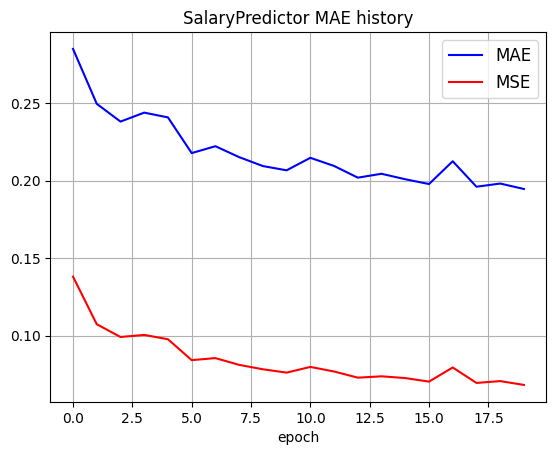

In [ ]:
training_cycle(SalaryPredictor(), num_epochs=20)

#### A) CNN architecture

All the tricks you know about dense and convolutional neural networks apply here as well.
* Dropout. Nuff said.
* Batch Norm. This time it's `nn.BatchNorm*`/`L.BatchNormalization`
* Parallel convolution layers. The idea is that you apply several nn.Conv1d to the same embeddings and concatenate output channels.
* More layers, more neurons, ya know...

In [ ]:
class SalaryPredictor_A(nn.Module):
    def __init__(self, n_tokens=len(tokens), n_cat_features=len(categorical_vectorizer.vocabulary_), hid_size=64):
        super().__init__()
        #self.hid_size = hid_size

        # Shared embedding layer
        self.embedding = nn.Embedding(n_tokens, 32)

        # Parallel convolution layers with different kernel sizes
        self.conv1 = nn.Sequential(
            nn.Conv1d(32, hid_size // 4, kernel_size=2, padding=1),  # for bigrams
            nn.BatchNorm1d(hid_size // 4),
            nn.ReLU()
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(32, hid_size // 4, kernel_size=3, padding=1),  # for trigrams
            nn.BatchNorm1d(hid_size // 4),
            nn.ReLU()
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(32, hid_size // 4, kernel_size=4, padding=2),  # for 4-grams
            nn.BatchNorm1d(hid_size // 4),
            nn.ReLU()
        )
        self.conv4 = nn.Sequential(
            nn.Conv1d(32, hid_size // 4, kernel_size=5, padding=2),  # for 5-grams
            nn.BatchNorm1d(hid_size // 4),
            nn.ReLU()
        )

        self.linear = nn.Sequential(
            nn.Linear(n_cat_features, hid_size),
            nn.BatchNorm1d(hid_size),
            nn.ReLU()
        )

        self.fc = nn.Sequential(
            nn.Linear(2 * hid_size + (hid_size // 4) * 4, hid_size),  # Adjusted for concatenated conv outputs
            #nn.BatchNorm1d(hid_size),
            nn.Dropout(0.2),
            nn.ReLU(),
            nn.Linear(hid_size, 1),
            nn.ReLU()
        )

    def forward(self, batch):
        # Process Title
        title_emb = self.embedding(batch["Title"])
        title_emb = title_emb.permute(0, 2, 1)  # [batch, channels, seq_len]

        # Apply parallel convolutions to title
        title_conv1 = self.conv1(title_emb)
        title_conv2 = self.conv2(title_emb)
        title_conv3 = self.conv3(title_emb)
        title_conv4 = self.conv4(title_emb)

        # Max pooling and concatenate
        title_pool1 = torch.max(title_conv1, dim=-1).values
        title_pool2 = torch.max(title_conv2, dim=-1).values
        title_pool3 = torch.max(title_conv3, dim=-1).values
        title_pool4 = torch.max(title_conv4, dim=-1).values

        title_combined = torch.cat([title_pool1, title_pool2, title_pool3, title_pool4], dim=1)

        # Process FullDescription
        desc_emb = self.embedding(batch["FullDescription"])
        desc_emb = desc_emb.permute(0, 2, 1)  # [batch, channels, seq_len]

        # Apply parallel convolutions to description
        desc_conv1 = self.conv1(desc_emb)
        desc_conv2 = self.conv2(desc_emb)
        desc_conv3 = self.conv3(desc_emb)
        desc_conv4 = self.conv4(desc_emb)

        # Max pooling and concatenate
        desc_pool1 = torch.max(desc_conv1, dim=-1).values
        desc_pool2 = torch.max(desc_conv2, dim=-1).values
        desc_pool3 = torch.max(desc_conv3, dim=-1).values
        desc_pool4 = torch.max(desc_conv4, dim=-1).values

        desc_combined = torch.cat([desc_pool1, desc_pool2, desc_pool3, desc_pool4], dim=1)

        # Process categorical features
        cat_feat = self.linear(batch["Categorical"])

        # Combine all features
        combined = torch.cat([title_combined, desc_combined, cat_feat], dim=1)
        return self.fc(combined).squeeze(-1)

  0%|          | 0/20 [00:00<?, ?it/s]

 results:
Mean square error: 0.13473
Mean absolute error: 0.28274
 results:
Mean square error: 0.11975
Mean absolute error: 0.26600
 results:
Mean square error: 0.11083
Mean absolute error: 0.25415
 results:
Mean square error: 0.10501
Mean absolute error: 0.24663
 results:
Mean square error: 0.10272
Mean absolute error: 0.24300
 results:
Mean square error: 0.09839
Mean absolute error: 0.23715
 results:
Mean square error: 0.09563
Mean absolute error: 0.23387
 results:
Mean square error: 0.09462
Mean absolute error: 0.23278
 results:
Mean square error: 0.09364
Mean absolute error: 0.23000
 results:
Mean square error: 0.09098
Mean absolute error: 0.22683
 results:
Mean square error: 0.09039
Mean absolute error: 0.22556
 results:
Mean square error: 0.08975
Mean absolute error: 0.22507
 results:
Mean square error: 0.09263
Mean absolute error: 0.22776
 results:
Mean square error: 0.08801
Mean absolute error: 0.22240
 results:
Mean square error: 0.08971
Mean absolute error: 0.22402
 results:


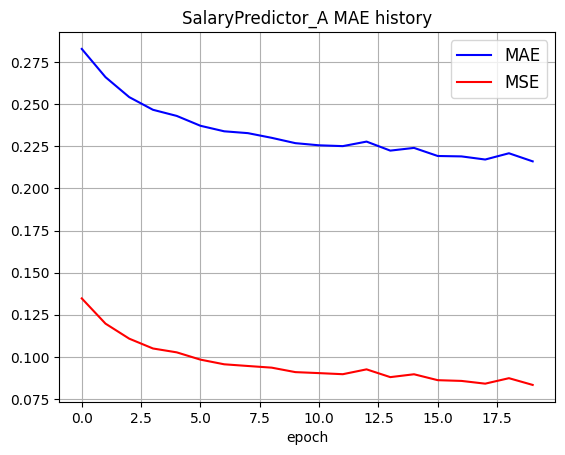

In [ ]:
training_cycle(SalaryPredictor_A(), num_epochs=20)

#### D) Going recurrent

We've already learned that recurrent networks can do cool stuff in sequence modelling. Turns out, they're not useless for classification as well. With some tricks of course..

* Like convolutional layers, LSTM should be pooled into a fixed-size vector with some of the poolings.
* Since you know all the text in advance, use bidirectional RNN
  * Run one LSTM from left to right
  * Run another in parallel from right to left
  * Concatenate their output sequences along unit axis (dim=-1)

* It might be good idea to mix convolutions and recurrent layers differently for title and description

In [ ]:
class SalaryPredictor_D(nn.Module):
    def __init__(self, n_tokens=len(tokens), n_cat_features=len(categorical_vectorizer.vocabulary_), hid_size=64):
        super().__init__()
        self.hid_size = hid_size

        # Title encoder: Mix of convolution and bidirectional LSTM
        self.title_enc = nn.Sequential(
            nn.Embedding(n_tokens, 32),
            Permute(dims=[0, 2, 1]),
            nn.Conv1d(32, hid_size, kernel_size=3),
            nn.ReLU(),
            Permute(dims=[0, 2, 1])  # Back to (batch, seq, features) for LSTM
        )

        # Description encoder: Only bidirectional LSTM
        self.desc_emb = nn.Embedding(n_tokens, 32)

        # Bidirectional LSTM layers
        self.title_lstm = nn.LSTM(
            input_size=hid_size,
            hidden_size=hid_size,
            batch_first=True,
            bidirectional=True
        )

        self.desc_lstm = nn.LSTM(
            input_size=32,
            hidden_size=hid_size,
            batch_first=True,
            bidirectional=True
        )

        self.linear = nn.Linear(n_cat_features, hid_size)

        self.fc = nn.Sequential(
            nn.Linear(5 * hid_size, hid_size),  # 5*hid_size because bidirectional doubles the output
            nn.ReLU(),
            nn.Linear(hid_size, 1),
            nn.ReLU()
        )

    def forward(self, batch):
        # Title processing: Conv + Bidirectional LSTM
        title_conv = self.title_enc(batch["Title"])
        title_lstm_out, _ = self.title_lstm(title_conv)

        # Get both directions' outputs and concatenate along unit axis (dim=-1)
        # title_lstm_out shape: (batch, seq_len, 2*hid_size) - already concatenated by LSTM
        title_pooled = torch.max(title_lstm_out, dim=1).values  # Max pooling over sequence

        # Description processing: Only Bidirectional LSTM
        desc_emb = self.desc_emb(batch["FullDescription"])
        desc_lstm_out, _ = self.desc_lstm(desc_emb)

        # Get both directions' outputs and concatenate along unit axis (dim=-1)
        # desc_lstm_out shape: (batch, seq_len, 2*hid_size) - already concatenated by LSTM
        desc_pooled = torch.max(desc_lstm_out, dim=1).values  # Max pooling over sequence

        cat_feat = self.linear(batch["Categorical"])

        # Concatenate all features: title (2*hid_size), description (2*hid_size), categorical (hid_size)
        combined = torch.cat([title_pooled, desc_pooled, cat_feat], dim=1)

        return self.fc(combined).squeeze(-1)

  0%|          | 0/20 [00:00<?, ?it/s]

 results:
Mean square error: 0.15116
Mean absolute error: 0.30070
 results:
Mean square error: 0.12917
Mean absolute error: 0.27654
 results:
Mean square error: 0.12034
Mean absolute error: 0.26759
 results:
Mean square error: 0.11465
Mean absolute error: 0.25747
 results:
Mean square error: 0.10572
Mean absolute error: 0.24721
 results:
Mean square error: 0.10150
Mean absolute error: 0.24262
 results:
Mean square error: 0.10012
Mean absolute error: 0.23993
 results:
Mean square error: 0.10249
Mean absolute error: 0.24652
 results:
Mean square error: 0.10201
Mean absolute error: 0.24628
 results:
Mean square error: 0.09275
Mean absolute error: 0.23012
 results:
Mean square error: 0.09531
Mean absolute error: 0.23642
 results:
Mean square error: 0.09006
Mean absolute error: 0.22750
 results:
Mean square error: 0.09575
Mean absolute error: 0.23385
 results:
Mean square error: 0.08742
Mean absolute error: 0.22321
 results:
Mean square error: 0.08685
Mean absolute error: 0.22205
 results:


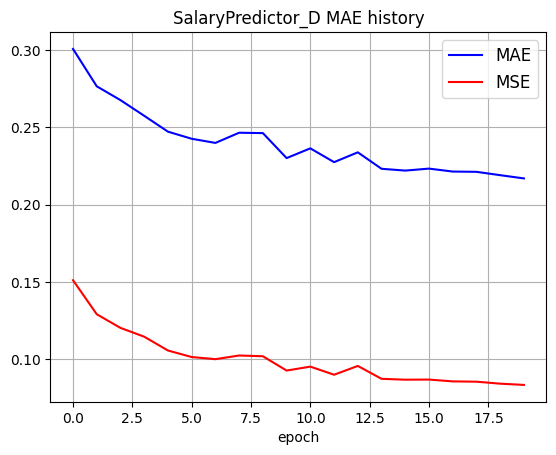

In [ ]:
training_cycle(SalaryPredictor_D(), num_epochs=20)

#### E) Optimizing seriously

* You don't necessarily need 100 epochs. Use early stopping. If you've never done this before, take a look at [early stopping callback(keras)](https://keras.io/callbacks/#earlystopping) or in [pytorch(lightning)](https://pytorch-lightning.readthedocs.io/en/latest/common/early_stopping.html).
  * In short, train until you notice that validation
  * Maintain the best-on-validation snapshot via `model.save(file_name)`
  * Plotting learning curves is usually a good idea

In [ ]:
class EarlyStopping:
    def __init__(self, tolerance=5, min_delta=0.01):

        self.tolerance = tolerance
        self.min_delta = min_delta
        self.counter = 0
        self.early_stop = False

    def __call__(self, last, this):
        if np.abs(last - this) < self.min_delta:
            self.counter +=1
            if self.counter >= self.tolerance:
                self.early_stop = True




In [ ]:
def training_cycle_E(model, learning_rate=1e-04, num_epochs=EPOCHS):
  model_name = str(f"{model}".split('(')[0])
  model = model.to(device)
  criterion = nn.MSELoss(reduction='sum')
  optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
  history = {'MAE':[], 'MSE': []}
  early_stopping = EarlyStopping()
  emae0, emse0 = 0, 0

  for epoch in tqdm(range(num_epochs)):
      #print(f"epoch: {epoch}")
      model.train()
      for i, batch in enumerate(
            iterate_minibatches(data_train, batch_size=BATCH_SIZE, device=device)):
          pred = model(batch)
          loss = criterion(pred, batch[TARGET_COLUMN])
          optimizer.zero_grad()
          loss.backward()
          optimizer.step()

      emse, emae = print_metrics(model, data_val, device=device)
      early_stopping(emse0, emse)
      if early_stopping.early_stop:
        print("We are at epoch:", epoch)
        break
      emse0, emae0 = emse, emae
      history['MAE'].append(emae)
      history['MSE'].append(emse)

  # Save to file
  with open(f'{model_name}_E_hist', 'wb') as file:
    pickle.dump(history, file)


  plt.plot(history['MAE'], label='MAE', color='blue')
  plt.plot(history['MSE'], label='MSE', color='red')
  #plt.plot([0, 1], [0, 1], '--', color='black',)
  plt.legend(fontsize='large')
  plt.xlabel("epoch")
  plt.grid()
  plt.title(f"{model_name} MAE history")
  plt.show()

  0%|          | 0/200 [00:00<?, ?it/s]

 results:
Mean square error: 0.23633
Mean absolute error: 0.38543
 results:
Mean square error: 0.24547
Mean absolute error: 0.40445
 results:
Mean square error: 0.12763
Mean absolute error: 0.27564
 results:
Mean square error: 0.18113
Mean absolute error: 0.34251
 results:
Mean square error: 0.11539
Mean absolute error: 0.26092
 results:
Mean square error: 0.15330
Mean absolute error: 0.31221
 results:
Mean square error: 0.11075
Mean absolute error: 0.25651
 results:
Mean square error: 0.11790
Mean absolute error: 0.26785
 results:
Mean square error: 0.09675
Mean absolute error: 0.23630
 results:
Mean square error: 0.09494
Mean absolute error: 0.23443
 results:
Mean square error: 0.08985
Mean absolute error: 0.22576
 results:
Mean square error: 0.13039
Mean absolute error: 0.28755
 results:
Mean square error: 0.11652
Mean absolute error: 0.26877
 results:
Mean square error: 0.13132
Mean absolute error: 0.29048
 results:
Mean square error: 0.08628
Mean absolute error: 0.22228
 results:


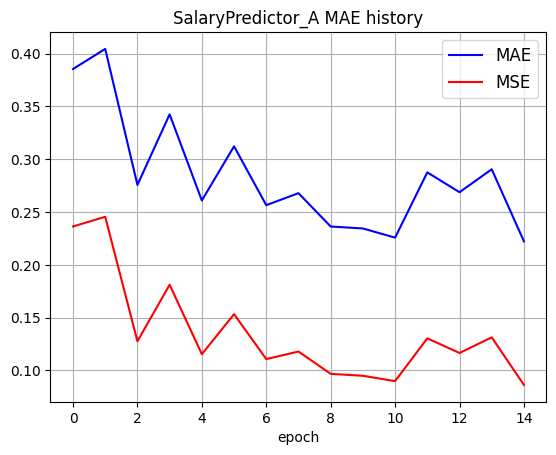

In [ ]:
training_cycle_E(SalaryPredictor_A())

  0%|          | 0/200 [00:00<?, ?it/s]

 results:
Mean square error: 0.11170
Mean absolute error: 0.25608
 results:
Mean square error: 0.09105
Mean absolute error: 0.22655
 results:
Mean square error: 0.08317
Mean absolute error: 0.21617
 results:
Mean square error: 0.07746
Mean absolute error: 0.20701
 results:
Mean square error: 0.07357
Mean absolute error: 0.20174
 results:
Mean square error: 0.06998
Mean absolute error: 0.19541
 results:
Mean square error: 0.07776
Mean absolute error: 0.20804
We are at epoch: 6


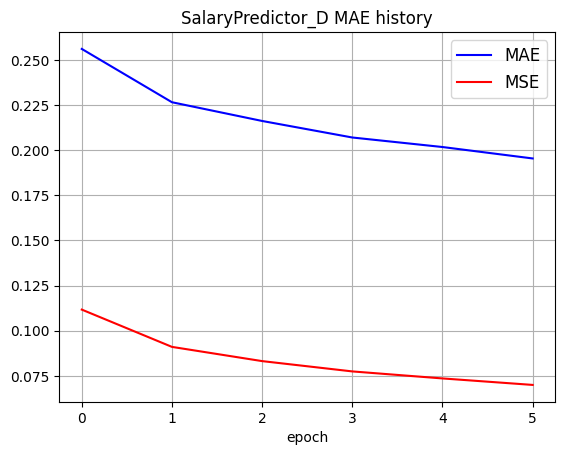

In [ ]:
training_cycle_E(SalaryPredictor_D())

### Bonus part: explaining model predictions

It's usually a good idea to understand how your model works before you let it make actual decisions. It's simple for linear models: just see which words learned positive or negative weights. However, its much harder for neural networks that learn complex nonlinear dependencies.

There are, however, some ways to look inside the black box:
* Seeing how model responds to input perturbations
* Finding inputs that maximize/minimize activation of some chosen neurons (_read more [on distill.pub](https://distill.pub/2018/building-blocks/)_)
* Building local linear approximations to your neural network: [article](https://arxiv.org/abs/1602.04938), [eli5 library](https://github.com/TeamHG-Memex/eli5/tree/master/eli5/formatters)

Today we gonna try the first method just because it's the simplest one.

In [ ]:
def explain(model, sample, col_name='Title'):
    """ Computes the effect each word had on model predictions """
    sample = dict(sample)
    sample_col_tokens = [tokens[token_to_id.get(tok, 0)] for tok in sample[col_name].split()]
    data_drop_one_token = pd.DataFrame([sample] * (len(sample_col_tokens) + 1))

    for drop_i in range(len(sample_col_tokens)):
        data_drop_one_token.loc[drop_i, col_name] = ' '.join(UNK if i == drop_i else tok
                                                   for i, tok in enumerate(sample_col_tokens))

    *predictions_drop_one_token, baseline_pred = model(make_batch(data_drop_one_token, device=device)).detach().cpu()
    diffs = baseline_pred - torch.Tensor(predictions_drop_one_token)
    return list(zip(sample_col_tokens, diffs))

In [ ]:
from IPython.display import HTML, display_html


def draw_html(tokens_and_weights, cmap=plt.get_cmap("bwr"), display=True,
              token_template="""<span style="background-color: {color_hex}">{token}</span>""",
              font_style="font-size:14px;"
             ):

    def get_color_hex(weight):
        rgba = cmap(1. / (1 + np.exp(float(weight))), bytes=True)
        return '#%02X%02X%02X' % rgba[:3]

    tokens_html = [
        token_template.format(token=token, color_hex=get_color_hex(weight))
        for token, weight in tokens_and_weights
    ]


    raw_html = """<p style="{}">{}</p>""".format(font_style, ' '.join(tokens_html))
    if display:
        display_html(HTML(raw_html))

    return raw_html


In [ ]:
i = 36605
tokens_and_weights = explain(model, data.loc[i], "Title")
draw_html([(tok, weight * 5) for tok, weight in tokens_and_weights], font_style='font-size:20px;');

tokens_and_weights = explain(model, data.loc[i], "FullDescription")
draw_html([(tok, weight * 10) for tok, weight in tokens_and_weights]);

In [ ]:
i = 12077
tokens_and_weights = explain(model, data.loc[i], "Title")
draw_html([(tok, weight * 5) for tok, weight in tokens_and_weights], font_style='font-size:20px;');

tokens_and_weights = explain(model, data.loc[i], "FullDescription")
draw_html([(tok, weight * 10) for tok, weight in tokens_and_weights]);

In [ ]:
i = np.random.randint(len(data))
print("Index:", i)
print("Salary (gbp):", np.expm1(model(make_batch(data.iloc[i: i+1], device=device)).detach().cpu()))

tokens_and_weights = explain(model, data.loc[i], "Title")
draw_html([(tok, weight * 5) for tok, weight in tokens_and_weights], font_style='font-size:20px;');

tokens_and_weights = explain(model, data.loc[i], "FullDescription")
draw_html([(tok, weight * 10) for tok, weight in tokens_and_weights]);

__Terrible start-up idea #1962:__ make a tool that automaticaly rephrases your job description (or CV) to meet salary expectations :)